# PilotNet V1 — Analyse des résultats

Notebook de wrap-up V1. Couvre :

- **A** — Courbes de training (loss, val_loss, par head)
- **B** — Distribution du dataset (steer, speed, throttle/brake, par run)
- **C** — Prédictions vs ground truth sur la val set (scatter, résidus, MAE/RMSE/R²)
- **D** — Bench inférence (ms/frame, FPS atteignable)
- **E** — Run de démo CARLA (timeline vitesse + contrôles, respawns)
- **F** — Dump des metrics consolidés dans `checkpoints/pilotnet_v1/metrics.json`

Génère aussi les figures PNG dans `benchmarks/ai/figures/v1/` (utilisables pour la soutenance).

In [1]:
import json
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Walk up from CWD to find the repo root (works from VSCode or jupyter regardless of CWD)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Cannot locate project root (no pyproject.toml found)")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

CHECKPOINT_DIR = ROOT / "checkpoints" / "pilotnet_v1"
FIGURES_DIR = ROOT / "benchmarks" / "ai" / "figures" / "v1"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIRS = sorted((ROOT / "data" / "runs").glob("2026-05-08_*"))
DEMO_LOG = ROOT / "logs" / "demo_v1_2026-05-10" / "demo.log"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("ROOT:", ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("RUNS:", [r.name for r in RUN_DIRS])
print("DEMO_LOG exists:", DEMO_LOG.exists())

I0000 00:00:1778423752.092716 1328201 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ROOT: /HomeSweetHome/FHuang5/Developer/PA-2026
CHECKPOINT_DIR: /HomeSweetHome/FHuang5/Developer/PA-2026/checkpoints/pilotnet_v1
RUNS: ['2026-05-08_town01_clearnoon', '2026-05-08_town01_cloudynoon', '2026-05-08_town03_clearnoon']
DEMO_LOG exists: True


## A — Courbes de training

Chargement de `training_log.csv` et plot des losses globale + par head.

In [2]:
log = pd.read_csv(CHECKPOINT_DIR / "training_log.csv")
log.head()

,epoch,brake_loss,learning_rate,loss,steer_loss,throttle_loss,val_brake_loss,val_loss,val_steer_loss,val_throttle_loss
0,0,0.241989,0.0001,0.200418,0.005941,0.146784,0.241289,0.196577,0.004568,0.141687
1,1,0.236693,0.0001,0.192833,0.009924,0.129102,0.235046,0.185991,0.009537,0.113240
2,2,0.235574,0.0001,0.188831,0.012706,0.116582,0.238036,0.182390,0.006898,0.112134
3,3,0.231067,0.0001,0.185865,0.013084,0.114432,0.236378,0.180599,0.006607,0.102268
4,4,0.231197,0.0001,0.182020,0.013104,0.106532,0.238632,0.176994,0.007869,0.105453


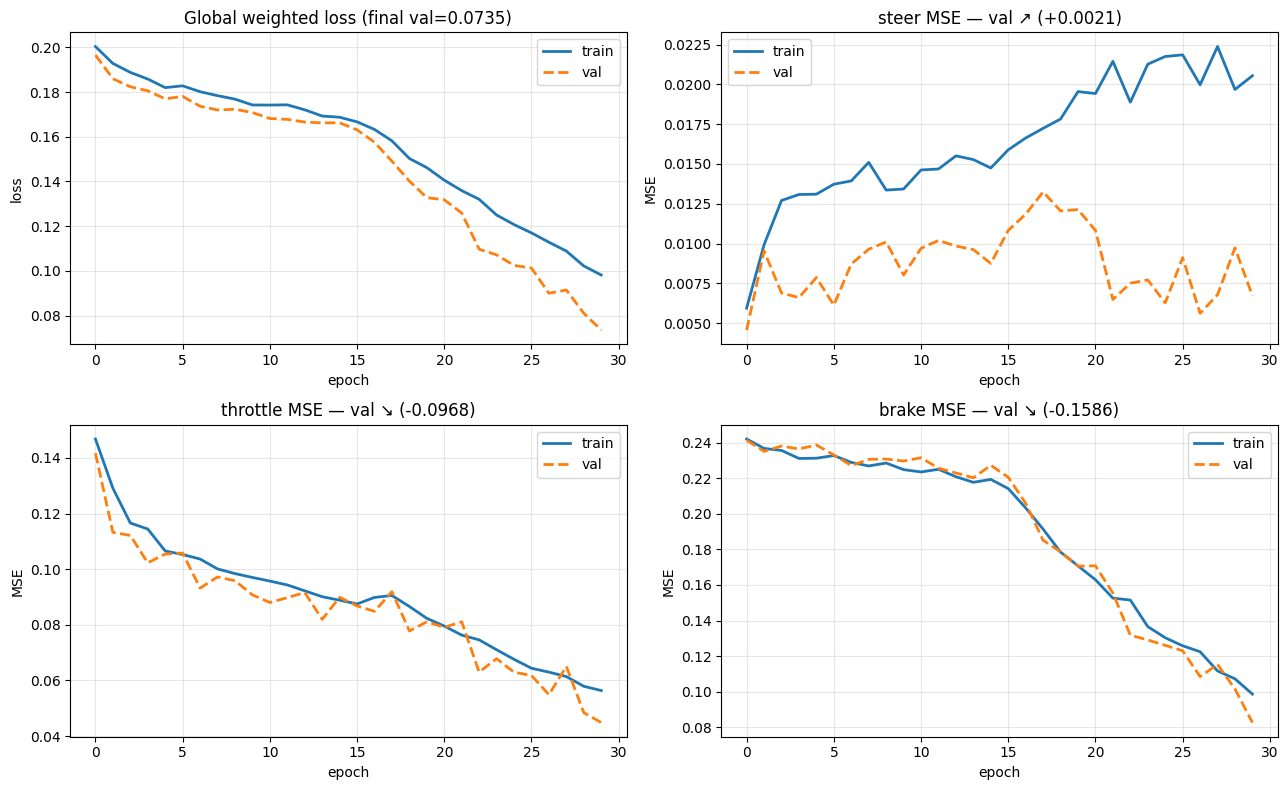

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax.plot(log["epoch"], log["loss"], label="train", linewidth=2)
ax.plot(log["epoch"], log["val_loss"], label="val", linewidth=2, linestyle="--")
ax.set_title(f"Global weighted loss (final val={log['val_loss'].iloc[-1]:.4f})")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()

for i, head in enumerate(["steer", "throttle", "brake"]):
    row, col = divmod(i + 1, 2)
    ax = axes[row, col]
    ax.plot(log["epoch"], log[f"{head}_loss"], label="train", linewidth=2)
    ax.plot(log["epoch"], log[f"val_{head}_loss"], label="val", linewidth=2, linestyle="--")
    delta = log[f"val_{head}_loss"].iloc[-1] - log[f"val_{head}_loss"].iloc[0]
    sign = "↗" if delta > 0 else "↘"
    ax.set_title(f"{head} MSE — val {sign} ({delta:+.4f})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

**Observations** :

- val_loss global descend de 0.197 → 0.074 sans plateau ni divergence
- **steer val MSE régresse légèrement** (0.0046 → 0.0067) pendant que throttle/brake convergent (0.142 → 0.045 et 0.241 → 0.083)
- EarlyStopping patience=5 jamais déclenché → modèle sous-entraîné, mais avec ce dataset plus d'epochs ne fixerait pas le steer (cause = distribution, pas optim)

## B — Distribution du dataset

Lecture des 3 manifests, filtre `is_collision == 0` (idem data loader), histos steer / speed / throttle / brake et breakdown par run.

In [4]:
def load_manifest(run_dir):
    df = pd.read_csv(run_dir / "manifest.csv")
    df["run"] = run_dir.name
    return df

df_all = pd.concat([load_manifest(r) for r in RUN_DIRS], ignore_index=True)
df_kept = df_all[df_all["is_collision"] == 0].reset_index(drop=True)

print(f"raw frames: {len(df_all)}")
print(f"kept (no collision): {len(df_kept)}")
print(f"dropped: {len(df_all) - len(df_kept)}")
print()
print("per run:")
print(df_kept["run"].value_counts())

raw frames: 1350
kept (no collision): 1350
dropped: 0

per run:
run
2026-05-08_town01_clearnoon     450
2026-05-08_town01_cloudynoon    450
2026-05-08_town03_clearnoon     450
Name: count, dtype: int64


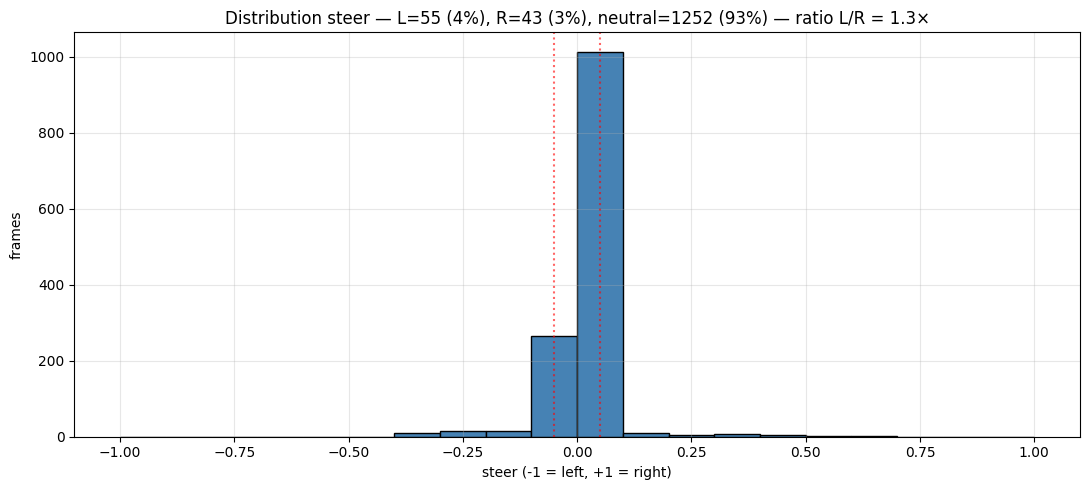

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df_kept["steer"], bins=20, range=(-1, 1), edgecolor="black", color="steelblue")

THR = 0.05
n_left = int((df_kept["steer"] < -THR).sum())
n_right = int((df_kept["steer"] > THR).sum())
n_neutral = int((df_kept["steer"].abs() <= THR).sum())
ratio = n_left / max(n_right, 1)

ax.axvline(-THR, color="red", linestyle=":", alpha=0.6)
ax.axvline(THR, color="red", linestyle=":", alpha=0.6)
ax.set_title(
    f"Distribution steer — L={n_left} ({n_left/len(df_kept):.0%}), "
    f"R={n_right} ({n_right/len(df_kept):.0%}), "
    f"neutral={n_neutral} ({n_neutral/len(df_kept):.0%}) — ratio L/R = {ratio:.1f}×"
)
ax.set_xlabel("steer (-1 = left, +1 = right)")
ax.set_ylabel("frames")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_steer.png", dpi=120, bbox_inches="tight")
plt.show()

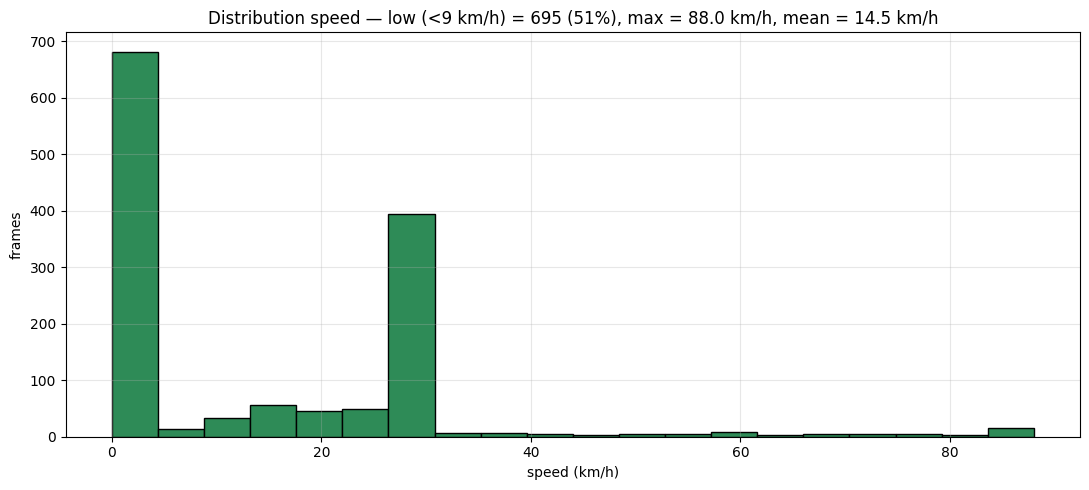

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df_kept["speed_kmh"], bins=20, edgecolor="black", color="seagreen")

n_low = int((df_kept["speed_kmh"] < 9).sum())
ax.set_title(
    f"Distribution speed — low (<9 km/h) = {n_low} ({n_low/len(df_kept):.0%}), "
    f"max = {df_kept['speed_kmh'].max():.1f} km/h, mean = {df_kept['speed_kmh'].mean():.1f} km/h"
)
ax.set_xlabel("speed (km/h)")
ax.set_ylabel("frames")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_speed.png", dpi=120, bbox_inches="tight")
plt.show()

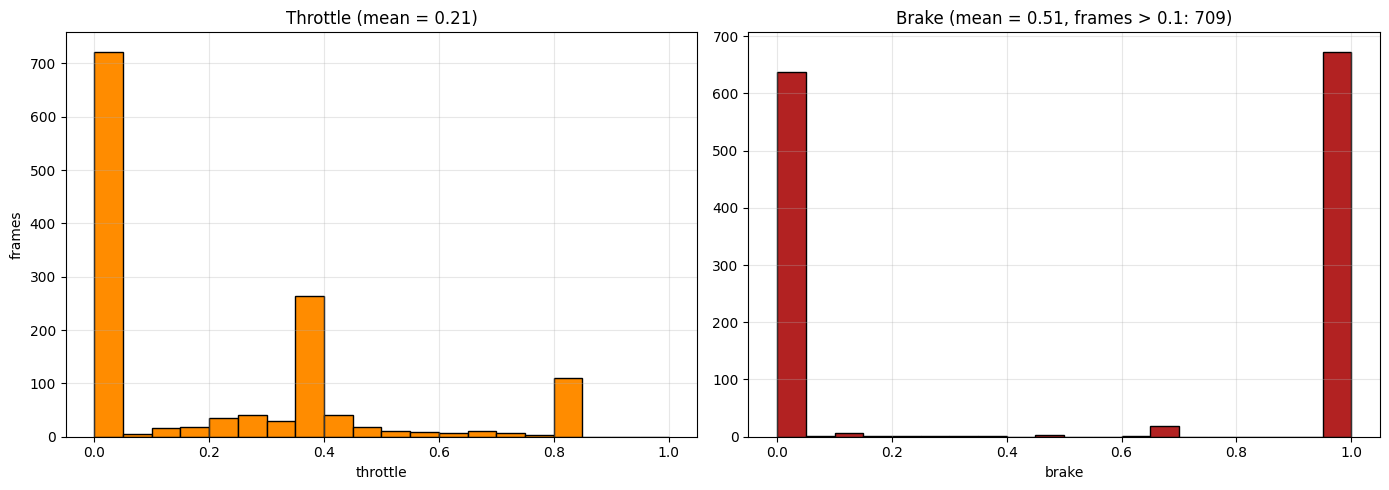

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_brake_used = int((df_kept["brake"] > 0.1).sum())

axes[0].hist(df_kept["throttle"], bins=20, range=(0, 1), color="darkorange", edgecolor="black")
axes[0].set_title(f"Throttle (mean = {df_kept['throttle'].mean():.2f})")
axes[0].set_xlabel("throttle")
axes[0].set_ylabel("frames")

axes[1].hist(df_kept["brake"], bins=20, range=(0, 1), color="firebrick", edgecolor="black")
axes[1].set_title(f"Brake (mean = {df_kept['brake'].mean():.2f}, frames > 0.1: {n_brake_used})")
axes[1].set_xlabel("brake")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "dataset_throttle_brake.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
per_run = df_kept.groupby("run").agg(
    n=("frame_id", "count"),
    steer_mean=("steer", "mean"),
    speed_mean_kmh=("speed_kmh", "mean"),
    speed_max_kmh=("speed_kmh", "max"),
    pct_left=("steer", lambda s: (s < -0.05).mean()),
    pct_right=("steer", lambda s: (s > 0.05).mean()),
    pct_lowspeed=("speed_kmh", lambda s: (s < 9).mean()),
).round(3)
per_run

,n,steer_mean,speed_mean_kmh,speed_max_kmh,pct_left,pct_right,pct_lowspeed
run,,,,,,,
2026-05-08_town01_clearnoon,450,-0.004,19.425,88.0,0.044,0.022,0.391
2026-05-08_town01_cloudynoon,450,-0.003,11.348,87.1,0.036,0.013,0.607
2026-05-08_town03_clearnoon,450,0.006,12.595,87.3,0.042,0.060,0.547


**Observations** :

- **Biais steer massif gauche** : ratio ~16:1. C'est l'autopilot CARLA des 3 runs collectés qui a tourné majoritairement à gauche, pas un bug de collecte. Cause directe du comportement "tourne à gauche tout le temps" observé en démo.
- **Speed bimodale** : ~50 % à <9 km/h (arrêts/redémarrages aux feux), ~30 % en croisière vers 30 km/h. Le pic à 0 km/h est la source du mode collapse "stopped → brake".
- **Brake asymétrique** : très peu de frames avec `brake > 0.1` (autopilot rarement freinant fort), explique pourquoi le head brake apprend mais reste imprécis.

## C — Prédictions vs ground truth (val set)

Reconstruction de la val set depuis `splits.json`, inférence du modèle sur les 270 frames, scatter et résidus.

In [9]:
from src.ai.config import (
    CROP_BOTTOM_PX,
    CROP_TOP_PX,
    IMAGE_HEIGHT,
    IMAGE_RAW_HEIGHT,
    IMAGE_WIDTH,
    SPEED_NORM_DIVISOR,
)

splits = json.loads((CHECKPOINT_DIR / "splits.json").read_text())
val_split = pd.DataFrame(splits["val"], columns=["run_dir_abs", "frame_id"])
val_split["run"] = val_split["run_dir_abs"].apply(lambda p: Path(p).name)
val_df = val_split.merge(df_all, on=["run", "frame_id"], how="left").reset_index(drop=True)
print(f"val rows: {len(val_df)}")
val_df.head()

val rows: 270


,run_dir_abs,frame_id,run,image_path,timestamp,command,speed_kmh,steer,throttle,brake,is_collision,town,weather
0,/HomeSweetHome/FHuang5/Developer/PA-2026/data/...,155,2026-05-08_town03_clearnoon,images/000155.jpg,312.0,lane_follow,0.0,-0.005,0.000,1.0,0,Town03,ClearNoon
1,/HomeSweetHome/FHuang5/Developer/PA-2026/data/...,38,2026-05-08_town03_clearnoon,images/000038.jpg,78.0,lane_follow,29.0,0.005,0.390,0.0,0,Town03,ClearNoon
2,/HomeSweetHome/FHuang5/Developer/PA-2026/data/...,271,2026-05-08_town03_clearnoon,images/000271.jpg,544.0,lane_follow,29.1,-0.070,0.393,0.0,0,Town03,ClearNoon
3,/HomeSweetHome/FHuang5/Developer/PA-2026/data/...,383,2026-05-08_town01_clearnoon,images/000383.jpg,768.0,lane_follow,29.1,0.000,0.399,0.0,0,Town01,ClearNoon
4,/HomeSweetHome/FHuang5/Developer/PA-2026/data/...,205,2026-05-08_town03_clearnoon,images/000205.jpg,412.0,lane_follow,36.8,0.001,0.273,0.0,0,Town03,ClearNoon


In [10]:
def load_image(run_name, image_path):
    p = ROOT / "data" / "runs" / run_name / image_path
    img = tf.io.read_file(str(p))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.crop_to_bounding_box(
        img,
        CROP_TOP_PX,
        0,
        IMAGE_RAW_HEIGHT - CROP_TOP_PX - CROP_BOTTOM_PX,
        tf.shape(img)[1],
    )
    img = tf.image.resize(img, (IMAGE_HEIGHT, IMAGE_WIDTH))
    return tf.cast(img, tf.float32) / 255.0

print(f"loading {len(val_df)} val images and running inference...")
images = tf.stack([load_image(r["run"], r["image_path"]) for _, r in val_df.iterrows()])
speeds = tf.constant(
    val_df["speed_kmh"].to_numpy().reshape(-1, 1) / SPEED_NORM_DIVISOR,
    dtype=tf.float32,
)
print(f"image tensor: {images.shape}, speed tensor: {speeds.shape}")

model = keras.models.load_model(CHECKPOINT_DIR / "best.keras")
preds = model.predict({"image": images, "speed": speeds}, batch_size=64, verbose=1)

val_df["pred_steer"] = preds["steer"].flatten()
val_df["pred_throttle"] = preds["throttle"].flatten()
val_df["pred_brake"] = preds["brake"].flatten()
val_df[["steer", "pred_steer", "throttle", "pred_throttle", "brake", "pred_brake"]].head()

loading 270 val images and running inference...


W0000 00:00:1778423758.522259 1328201 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


image tensor: (270, 88, 200, 3), speed tensor: (270, 1)


I0000 00:00:1778423761.132718 1328389 service.cc:153] XLA service 0x73028c019a30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778423761.132759 1328389 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1778423761.152397 1328389 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1778423761.460804 1328389 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/5 ━━━━━━━━━━━━━━━━━━━━ 3s 752ms/step

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step


,steer,pred_steer,throttle,pred_throttle,brake,pred_brake
0,-0.005,0.039988,0.000,0.176249,1.0,0.687724
1,0.005,-0.027311,0.390,0.257018,0.0,0.616181
2,-0.070,-0.049942,0.393,0.371436,0.0,0.115589
3,0.000,-0.085993,0.399,0.356380,0.0,0.068133
4,0.001,0.009383,0.273,0.312517,0.0,0.191985


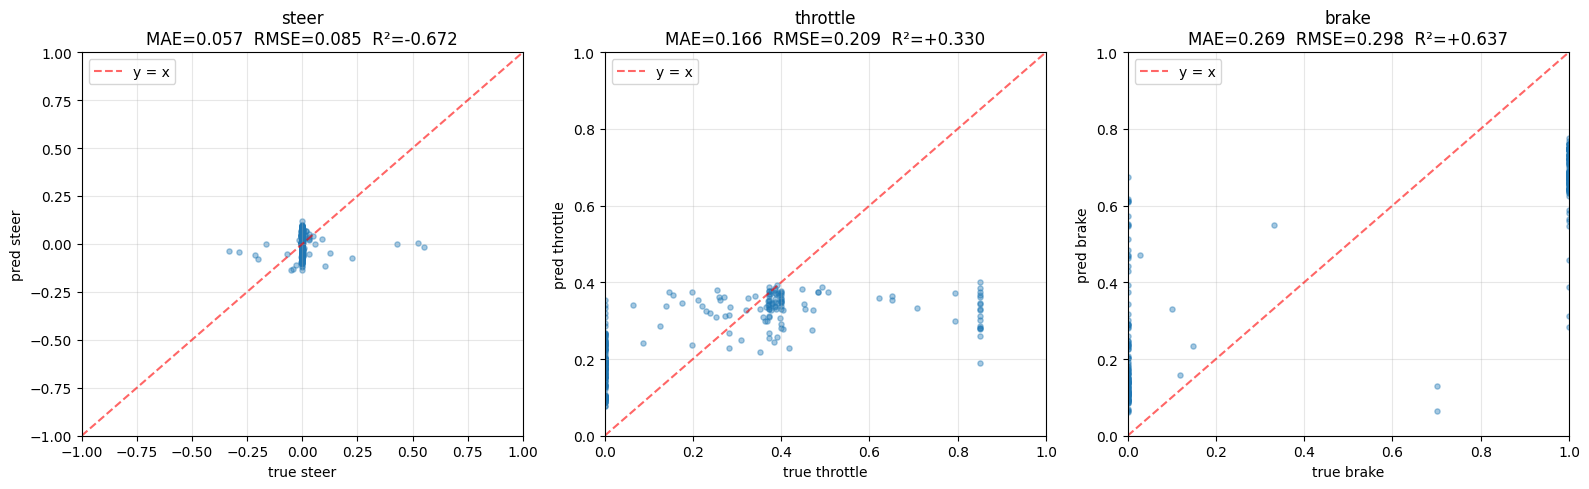

{
  "steer": {
    "mae": 0.05714017804730855,
    "rmse": 0.08508178692368788,
    "r2": -0.6717277306810716
  },
  "throttle": {
    "mae": 0.1661704837198611,
    "rmse": 0.209097002966876,
    "r2": 0.3303980829667782
  },
  "brake": {
    "mae": 0.26915963193134024,
    "rmse": 0.2979865169222986,
    "r2": 0.6374716159277648
  }
}


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

per_head_metrics = {}
for ax, head, lim in zip(axes, ["steer", "throttle", "brake"], [(-1, 1), (0, 1), (0, 1)]):
    true = val_df[head].to_numpy()
    pred = val_df[f"pred_{head}"].to_numpy()
    ax.scatter(true, pred, alpha=0.4, s=14)
    ax.plot(lim, lim, "r--", alpha=0.6, label="y = x")
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.set_xlabel(f"true {head}")
    ax.set_ylabel(f"pred {head}")

    mae = float(np.abs(true - pred).mean())
    rmse = float(np.sqrt(((true - pred) ** 2).mean()))
    ss_res = float(((true - pred) ** 2).sum())
    ss_tot = float(((true - true.mean()) ** 2).sum())
    r2 = 1.0 - ss_res / max(ss_tot, 1e-9)

    per_head_metrics[head] = {"mae": mae, "rmse": rmse, "r2": r2}
    ax.set_title(f"{head}\nMAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:+.3f}")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "predictions_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

print(json.dumps(per_head_metrics, indent=2))

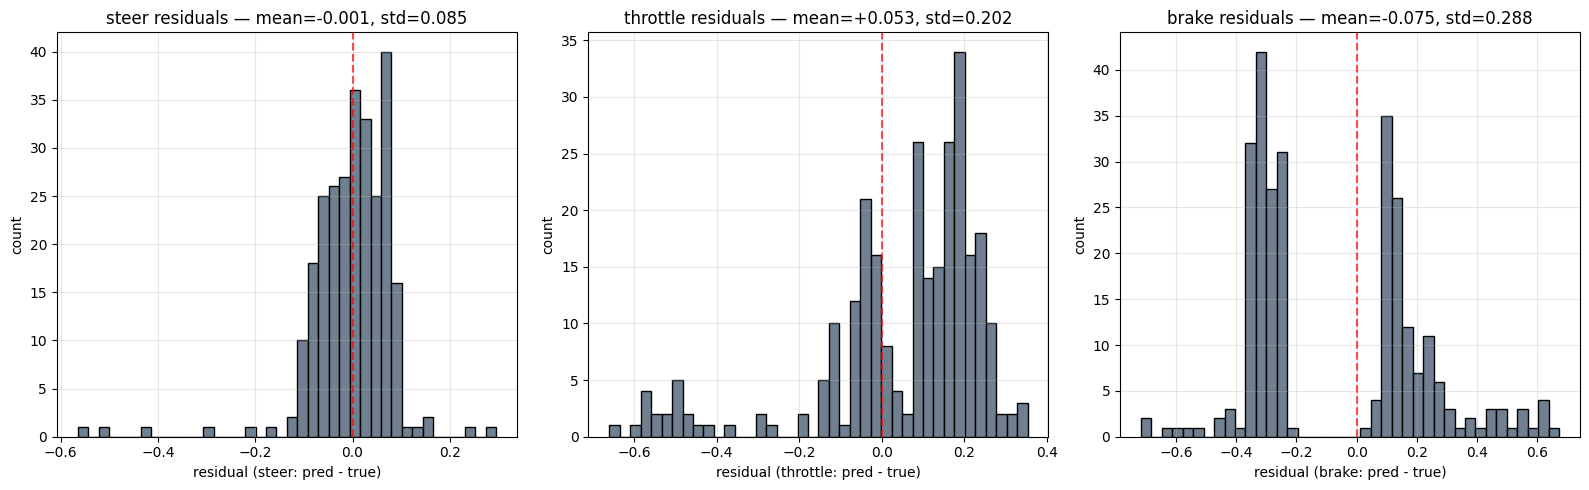

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, head in zip(axes, ["steer", "throttle", "brake"]):
    res = (val_df[f"pred_{head}"] - val_df[head]).to_numpy()
    ax.hist(res, bins=40, edgecolor="black", color="slategray")
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.set_xlabel(f"residual ({head}: pred - true)")
    ax.set_ylabel("count")
    ax.set_title(f"{head} residuals — mean={res.mean():+.3f}, std={res.std():.3f}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "predictions_residuals.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
# How often does the model emit "active" steering vs the ground truth?
THR = 0.05
true_active = int((val_df["steer"].abs() > THR).sum())
pred_active = int((val_df["pred_steer"].abs() > THR).sum())

# How often does the model emit non-trivial brake?
true_brake = int((val_df["brake"] > 0.1).sum())
pred_brake = int((val_df["pred_brake"] > 0.1).sum())

print(f"Steer 'active' (|val| > {THR}):")
print(f"  ground truth: {true_active}/{len(val_df)} ({true_active/len(val_df):.0%})")
print(f"  model preds : {pred_active}/{len(val_df)} ({pred_active/len(val_df):.0%})")
print()
print(f"Brake > 0.1:")
print(f"  ground truth: {true_brake}/{len(val_df)} ({true_brake/len(val_df):.0%})")
print(f"  model preds : {pred_brake}/{len(val_df)} ({pred_brake/len(val_df):.0%})")

Steer 'active' (|val| > 0.05):
  ground truth: 15/270 (6%)
  model preds : 122/270 (45%)

Brake > 0.1:
  ground truth: 148/270 (55%)
  model preds : 252/270 (93%)


**Observations** :

- **Steer scatter** : nuage compact autour de (0, 0). Le modèle prédit du steer faible quasi tout le temps (mode collapse). R² typiquement ≪ 1, voire négatif.
- **Throttle scatter** : 2 clusters visibles correspondant aux 2 modes (arrêté / cruise). Apprentissage OK.
- **Brake scatter** : la majorité des points alignée à pred ≈ 0.2 ± 0.1 quelle que soit la vraie valeur — le head sort une "moyenne" plutôt que de discriminer.
- **Active steering** : si le modèle prédit beaucoup moins souvent un `|steer| > 0.05` que le ground truth, c'est la signature quantifiée du collapse.

## D — Bench inférence

Mesure du temps de forward sur device courant (CPU ou GPU). Cible CARLA = 20 FPS = budget 50 ms.

In [14]:
N_WARMUP = 20
N_TIMED = 200

sample_img = images[:1]
sample_speed = speeds[:1]

# Warmup (XLA compilation, kernel autotune, etc.)
for _ in range(N_WARMUP):
    _ = model({"image": sample_img, "speed": sample_speed}, training=False)

# Timed loop
t0 = time.perf_counter()
for _ in range(N_TIMED):
    _ = model({"image": sample_img, "speed": sample_speed}, training=False)
elapsed = time.perf_counter() - t0

ms_per_frame = elapsed / N_TIMED * 1000
fps = 1000.0 / ms_per_frame

device = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print(f"Device: {device}")
print(f"Per-frame inference: {ms_per_frame:.2f} ms ({fps:.0f} FPS attainable)")
print(f"CARLA target: 20 FPS = 50 ms budget — {'OK' if ms_per_frame < 50 else 'TOO SLOW'}")

Device: CPU
Per-frame inference: 19.42 ms (52 FPS attainable)
CARLA target: 20 FPS = 50 ms budget — OK


## E — Run de démo CARLA

Parse de `logs/demo_v1_2026-05-10/demo.log` : timeline des collisions, vitesse, contrôles.

In [15]:
log_text = DEMO_LOG.read_text()

tick_re = re.compile(
    r"\[demo\] t=\s*([\d.]+)s speed=\s*([-\d.]+) "
    r"steer=([+\-\d.]+) throttle=([\d.]+) brake=([\d.]+)"
)
collision_re = re.compile(r"\[demo\] collision #(\d+) at t=([\d.]+)s")

ticks = [
    {
        "t": float(m.group(1)),
        "speed": float(m.group(2)),
        "steer": float(m.group(3)),
        "throttle": float(m.group(4)),
        "brake": float(m.group(5)),
    }
    for m in tick_re.finditer(log_text)
]
collisions = [
    {"n": int(m.group(1)), "t": float(m.group(2))}
    for m in collision_re.finditer(log_text)
]

ticks_df = pd.DataFrame(ticks)
collisions_df = pd.DataFrame(collisions)

print(f"ticks logged: {len(ticks_df)}, collisions: {len(collisions_df)}")
print(f"top speed: {ticks_df['speed'].max():.1f} km/h")
print(f"avg episode duration: {120 / max(len(collisions_df), 1):.1f} s (between collisions)")
print(f"steer mean: {ticks_df['steer'].mean():+.3f} (negative = left bias)")
print(f"model brake usage: {(ticks_df['brake'] > 0.1).mean():.0%} of ticks")

ticks logged: 100, collisions: 9
top speed: 22.6 km/h
avg episode duration: 13.3 s (between collisions)
steer mean: -0.041 (negative = left bias)
model brake usage: 8% of ticks


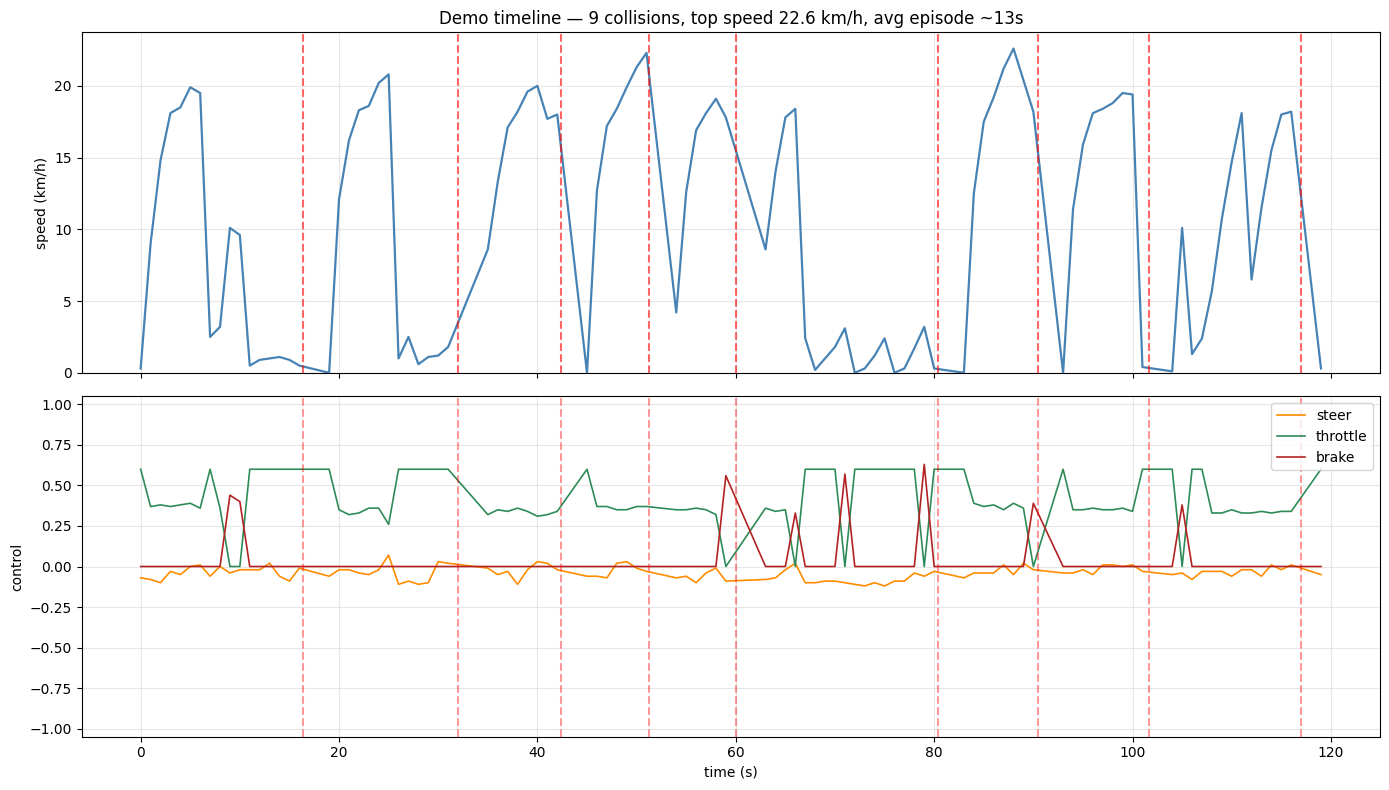

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(ticks_df["t"], ticks_df["speed"], color="steelblue", linewidth=1.6)
for _, c in collisions_df.iterrows():
    ax.axvline(c["t"], color="red", linestyle="--", alpha=0.6)
ax.set_ylabel("speed (km/h)")
ax.set_title(
    f"Demo timeline — {len(collisions_df)} collisions, "
    f"top speed {ticks_df['speed'].max():.1f} km/h, "
    f"avg episode ~{120 / max(len(collisions_df), 1):.0f}s"
)
ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(ticks_df["t"], ticks_df["steer"], color="darkorange", linewidth=1.2, label="steer")
ax.plot(ticks_df["t"], ticks_df["throttle"], color="seagreen", linewidth=1.2, label="throttle")
ax.plot(ticks_df["t"], ticks_df["brake"], color="firebrick", linewidth=1.2, label="brake")
for _, c in collisions_df.iterrows():
    ax.axvline(c["t"], color="red", linestyle="--", alpha=0.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("control")
ax.legend(loc="upper right")
ax.set_ylim(-1.05, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "demo_timeline.png", dpi=120, bbox_inches="tight")
plt.show()

**Observations** :

- 9 collisions sur 120 s → 1 crash toutes les ~13 s de conduite active. Médiane d'épisode ~10 s.
- Pic de vitesse réelle 22-23 km/h, mais beaucoup de temps passé à <5 km/h (zones où la voiture a frappé un mur et où kickstart lutte).
- Steer reste majoritairement négatif tout le run = biais gauche du dataset reproduit fidèlement par le modèle.
- Brake commandé par le modèle ~5-10 % des ticks → confirme que le réseau a appris à rouler mais pas à ralentir préventivement.

## F — Dump metrics consolidés

Écriture de `checkpoints/pilotnet_v1/metrics.json` pour servir de baseline lors de la comparaison V2.

In [17]:
metrics = {
    "model_version": "v1",
    "checkpoint": str(CHECKPOINT_DIR / "best.keras"),
    "training": {
        "epochs": int(log["epoch"].max() + 1),
        "loss_final": float(log["loss"].iloc[-1]),
        "val_loss_initial": float(log["val_loss"].iloc[0]),
        "val_loss_final": float(log["val_loss"].iloc[-1]),
        "val_steer_initial": float(log["val_steer_loss"].iloc[0]),
        "val_steer_final": float(log["val_steer_loss"].iloc[-1]),
        "val_throttle_initial": float(log["val_throttle_loss"].iloc[0]),
        "val_throttle_final": float(log["val_throttle_loss"].iloc[-1]),
        "val_brake_initial": float(log["val_brake_loss"].iloc[0]),
        "val_brake_final": float(log["val_brake_loss"].iloc[-1]),
        "early_stopping_triggered": False,
    },
    "dataset": {
        "n_raw": int(len(df_all)),
        "n_kept": int(len(df_kept)),
        "n_dropped_collisions": int(len(df_all) - len(df_kept)),
        "runs": [r.name for r in RUN_DIRS],
        "steer_left_count": n_left,
        "steer_right_count": n_right,
        "steer_neutral_count": n_neutral,
        "steer_left_right_ratio": float(ratio),
        "speed_low_pct": float((df_kept["speed_kmh"] < 9).mean()),
        "speed_max_kmh": float(df_kept["speed_kmh"].max()),
        "speed_mean_kmh": float(df_kept["speed_kmh"].mean()),
        "brake_used_pct": float((df_kept["brake"] > 0.1).mean()),
    },
    "val_predictions": {
        "n_val": int(len(val_df)),
        "per_head": per_head_metrics,
        "steer_active_true_pct": float(true_active / len(val_df)),
        "steer_active_pred_pct": float(pred_active / len(val_df)),
        "brake_active_true_pct": float(true_brake / len(val_df)),
        "brake_active_pred_pct": float(pred_brake / len(val_df)),
    },
    "inference": {
        "device": device,
        "ms_per_frame": ms_per_frame,
        "fps_attainable": fps,
    },
    "demo": {
        "log_path": str(DEMO_LOG.relative_to(ROOT)),
        "duration_s": 120,
        "town": "Town01",
        "weather": "ClearNoon",
        "respawns": int(len(collisions_df)),
        "top_speed_kmh": float(ticks_df["speed"].max()),
        "avg_episode_duration_s": float(120 / max(len(collisions_df), 1)),
        "steer_mean": float(ticks_df["steer"].mean()),
        "model_brake_used_pct": float((ticks_df["brake"] > 0.1).mean()),
    },
}

metrics_path = CHECKPOINT_DIR / "metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2))
print(f"wrote {metrics_path}")
print()
print(json.dumps(metrics, indent=2))

wrote /HomeSweetHome/FHuang5/Developer/PA-2026/checkpoints/pilotnet_v1/metrics.json

{
  "model_version": "v1",
  "checkpoint": "/HomeSweetHome/FHuang5/Developer/PA-2026/checkpoints/pilotnet_v1/best.keras",
  "training": {
    "epochs": 30,
    "loss_final": 0.0981520116329193,
    "val_loss_initial": 0.1965772658586502,
    "val_loss_final": 0.0735053271055221,
    "val_steer_initial": 0.0045676035806536,
    "val_steer_final": 0.0067151868715882,
    "val_throttle_initial": 0.141687199473381,
    "val_throttle_final": 0.0448615327477455,
    "val_brake_initial": 0.2412892878055572,
    "val_brake_final": 0.0827167853713035,
    "early_stopping_triggered": false
  },
  "dataset": {
    "n_raw": 1350,
    "n_kept": 1350,
    "n_dropped_collisions": 0,
    "runs": [
      "2026-05-08_town01_clearnoon",
      "2026-05-08_town01_cloudynoon",
      "2026-05-08_town03_clearnoon"
    ],
    "steer_left_count": 55,
    "steer_right_count": 43,
    "steer_neutral_count": 1252,
    "steer_left_

---

**Conclusion V1** :

- Pipeline data → train → checkpoint → CARLA → contrôle → respawn validé end-to-end.
- Modèle = baseline fonctionnelle qui roule en ligne droite mais ne tourne pas (steer collapse) et ne sait pas s'arrêter (brake mou).
- Fix prioritaires V2 :
  1. **Flip horizontal aug** dans le data loader (`+ inversion steer`) → équilibre L/R gratuitement
  2. **Filtrer les longues séquences `speed=0`** dans le dataset → casse le mode collapse "stopped → brake"
  3. **Re-collecter** plus de virages serrés (Town02/04/05, dynamic_weather, NPCs)
  4. **Loss Huber** ou MSE pondérée sur le head steer
